<a href="https://colab.research.google.com/github/mszhdgr/Machine_learning/blob/Main/Deep%20Learning/tens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import warnings

warnings.filterwarnings("ignore")

## Linear Regression

In [2]:
import kagglehub

path = kagglehub.dataset_download("ashydv/housing-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'housing-dataset' dataset.
Path to dataset files: /kaggle/input/housing-dataset


In [3]:
df = pd.read_csv("/kaggle/input/housing-dataset/Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [9]:
x = df.drop(columns=['price'])
x.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [12]:
labels = df['price'].values.ravel()
labels[:3]

array([13300000, 12250000, 12250000])

In [28]:
y = labels.reshape(-1, 1)
y[:4]

array([[13300000],
       [12250000],
       [12250000],
       [12215000]])

In [8]:
num_columns = ['area','bedrooms','bathrooms','stories','parking']
cat_columns = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea','furnishingstatus']

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

preprocessor = ColumnTransformer([
    ('num_processor', MinMaxScaler(), num_columns),
    ('cut_processor', OneHotEncoder(), cat_columns)
])
x_trans = preprocessor.fit_transform(x)

In [15]:
x_trans

array([[0.39656357, 0.6       , 0.33333333, ..., 1.        , 0.        ,
        0.        ],
       [0.5024055 , 0.6       , 1.        , ..., 1.        , 0.        ,
        0.        ],
       [0.57113402, 0.4       , 0.33333333, ..., 0.        , 1.        ,
        0.        ],
       ...,
       [0.13539519, 0.2       , 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.08659794, 0.4       , 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.15120275, 0.4       , 0.        , ..., 0.        , 0.        ,
        1.        ]])

In [41]:
scaler = MinMaxScaler()
y_trans = scaler.fit_transform(y)
y_trans[:5]

array([[1.        ],
       [0.90909091],
       [0.90909091],
       [0.90606061],
       [0.83636364]])

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x_trans, y_trans, test_size=0.2)
len(X_train), len(X_test)

(436, 109)

In [18]:
X_test.shape

(109, 20)

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()
model.add(Input(shape=(20,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='relu'))

In [43]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,459 (13.52 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [44]:
model.compile(optimizer='sgd', loss='mse')

In [46]:
history = model.fit(X_train, y_train, epochs=10)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0950 
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0950 
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0950 
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0950
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0950
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0950
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0950  
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0950 
Epoch 9/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0950  
Epoch 10/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0950 


## Binary Classification

In [50]:
from sklearn.datasets import make_moons

In [51]:
x, y = make_moons(n_samples=1000, noise=0.03, random_state=42)

In [52]:
x

array([[-0.00933187,  0.39098105],
       [ 0.95457387, -0.47375583],
       [ 0.9185256 , -0.42519648],
       ...,
       [ 1.65391483, -0.29179795],
       [-0.9341017 ,  0.35358221],
       [ 0.7968358 ,  0.60423662]])

In [54]:
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
len(X_train), len(X_test)

(800, 200)

In [56]:
X_train.shape

(800, 2)

In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model_0 = Sequential()
model_0.add(Input(shape=(2,)))
model_0.add(Dense(64, activation='relu'))
model_0.add(Dense(32, activation='relu'))
model_0.add(Dense(1, activation='sigmoid'))

In [58]:
model_0.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
model_0.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

In [72]:
history_0 = model_0.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test))

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8988 - loss: 0.2224 - val_accuracy: 0.8800 - val_loss: 0.2296
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9000 - loss: 0.2215 - val_accuracy: 0.8800 - val_loss: 0.2285
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9013 - loss: 0.2204 - val_accuracy: 0.8800 - val_loss: 0.2274
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9013 - loss: 0.2200 - val_accuracy: 0.8800 - val_loss: 0.2262
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9013 - loss: 0.2187 - val_accuracy: 0.8850 - val_loss: 0.2252
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8975 - loss: 0.2180 - val_accuracy: 0.8800 - val_loss: 0.2242
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9013 - loss: 0.2172 - val_accuracy: 0.8850 - val_loss: 0.2231
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9050 - loss: 0.2165 - val_accuracy: 0.8850 - 

In [75]:
accuracy = history_0.history['accuracy']
val_acc = history_0.history['val_accuracy']
loss = history_0.history['loss']
val_loss = history_0.history['val_loss']
epoch = history_0.epoch

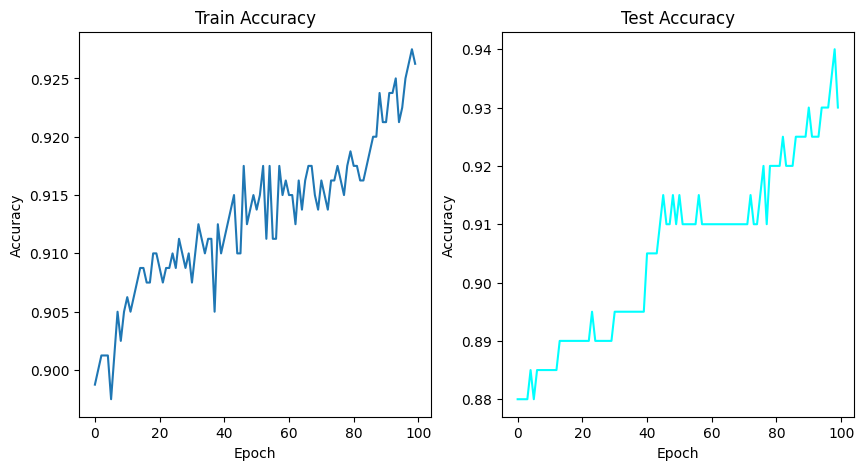

In [82]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].plot(epoch, accuracy)
ax[0].set_title("Train Accuracy")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")
ax[1].plot(epoch, val_acc, c="cyan")
ax[1].set_title("Test Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
plt.show()

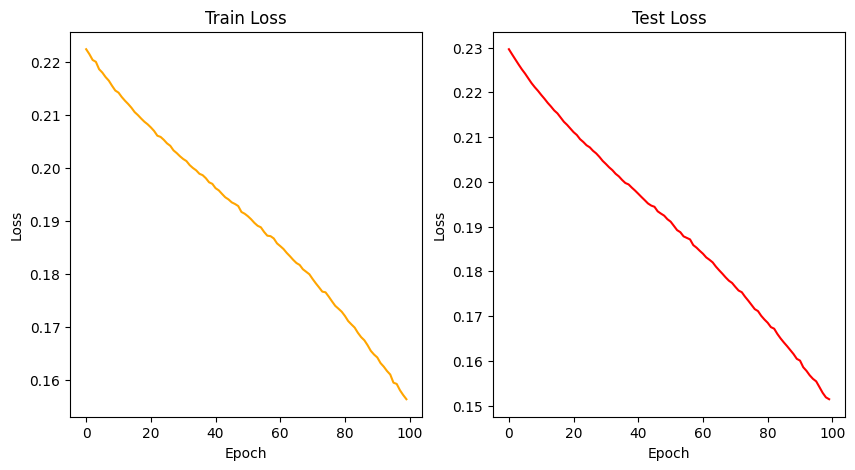

In [83]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].plot(epoch, loss, c="orange")
ax[0].set_title("Train Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[1].plot(epoch, val_loss, c="red")
ax[1].set_title("Test Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
plt.show()

## cnn

In [85]:
import kagglehub

path = kagglehub.dataset_download("datascientist97/forest-fire-dataset-binary-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'forest-fire-dataset-binary-classification' dataset.
Path to dataset files: /kaggle/input/forest-fire-dataset-binary-classification


In [86]:
from pathlib import Path

data_path = Path("/kaggle/input/forest-fire-dataset-binary-classification/Forest-Fire-Cleaned/Forest-Fire-Cleaned")
data_path

PosixPath('/kaggle/input/forest-fire-dataset-binary-classification/Forest-Fire-Cleaned/Forest-Fire-Cleaned')

In [93]:
all_imgs = list(data_path.glob("*/*/*.jpg"))
len(all_imgs)

6248

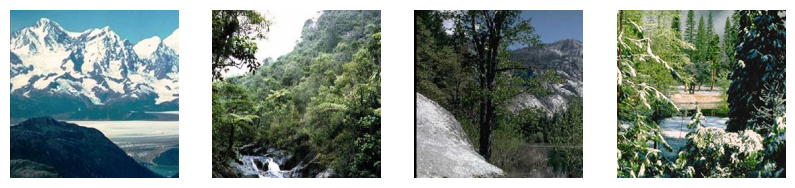

In [104]:
from PIL import Image
import random

Rand_paths = random.sample(all_imgs, k=4)

fig, ax = plt.subplots(1, 4, figsize=(10,5))
for i, pth in enumerate(Rand_paths):
  img = Image.open(pth)
  ax[i].imshow(img)
  ax[i].axis('off')

plt.show()

In [115]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

In [116]:
train_path = data_path/"train"
test_path = data_path/"test"

In [117]:
from tensorflow.keras.utils import image_dataset_from_directory

train_ds = image_dataset_from_directory(
    train_path,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=42,
    label_mode="int",
    subset="training",
    validation_split=0.2
)

Found 4350 files belonging to 2 classes.
Using 3480 files for training.


In [118]:
test_ds = image_dataset_from_directory(
    test_path,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=42,
    label_mode="int",
    subset="validation",
    validation_split=0.2
)

Found 1241 files belonging to 2 classes.
Using 248 files for validation.


In [119]:
class_names = train_ds.class_names
class_names

['fire', 'nofire']

In [120]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(buffer_size=1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [121]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense, Conv2D, MaxPooling2D, Flatten, Rescaling

model_1 = Sequential()
model_1.add(Input(shape=(64,64,3)))
model_1.add(Rescaling(1./255))
model_1.add(Conv2D(64, (3, 3), activation="relu"))
model_1.add(MaxPooling2D())
model_1.add(Conv2D(32, (3, 3), activation="relu"))
model_1.add(MaxPooling2D())
model_1.add(Flatten())
model_1.add(Dense(len(class_names), activation='sigmoid'))

In [122]:
model_1.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │        12,546 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,802 (128.13 KB)

 Trainable params: 32,802 (128.13 KB)

 Non-trainable params: 0 (0.00 B)

In [123]:
model_1.compile(optimizer="sgd", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [124]:
history_1 = model_1.fit(train_ds, validation_data=test_ds, epochs=10)

Epoch 1/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 51s 241ms/step - accuracy: 0.8204 - loss: 0.4419 - val_accuracy: 0.8911 - val_loss: 0.3214
Epoch 2/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 224ms/step - accuracy: 0.8796 - loss: 0.3077 - val_accuracy: 0.8871 - val_loss: 0.2740
Epoch 3/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 224ms/step - accuracy: 0.8874 - loss: 0.2747 - val_accuracy: 0.9153 - val_loss: 0.2131
Epoch 4/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 232ms/step - accuracy: 0.9037 - loss: 0.2396 - val_accuracy: 0.9032 - val_loss: 0.1956
Epoch 5/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 231ms/step - accuracy: 0.9032 - loss: 0.2294 - val_accuracy: 0.9315 - val_loss: 0.1827
Epoch 6/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 229ms/step - accuracy: 0.9095 - loss: 0.2223 - val_accuracy: 0.8992 - val_loss: 0.2025
Epoch 7/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 228ms/step - accuracy: 0.9161 - loss: 0.2167 - val_accuracy: 0.8911 - val_loss: 0.2028
Epoch 8/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 229ms/step - accuracy: 0.9124 - loss: 0

In [125]:
img = tf.keras.utils.load_img(
    "/fire.jpg",
    target_size=(64,64)
)

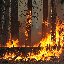

In [126]:
img

In [127]:
img_array = tf.keras.utils.img_to_array(img)
img_array.shape

(64, 64, 3)

In [128]:
img_expanded = tf.expand_dims(img_array, 0)
img_expanded.shape

TensorShape([1, 64, 64, 3])

In [129]:
pred = model_1.predict(img_expanded)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step


In [133]:
print("Model prediction (probabilities for each class):")
print(pred)

Model prediction (probabilities for each class):
[[0.85068    0.11943597]]


In [130]:
pred[0][0]

np.float32(0.85068)

In [146]:
if pred[0][0] > 0.5:
  print("Predicted Class - Fire")
else:
  print("Predicted Class - No Fire")

Predicted Class - Fire


In [134]:
img_2 = tf.keras.utils.load_img(
    "/images (1).jpg",
    target_size=(64,64)
)

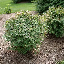

In [135]:
img_2

In [136]:
img2_arr = tf.keras.utils.img_to_array(img_2)
img2_arr.shape

(64, 64, 3)

In [137]:
img2_exp = tf.expand_dims(img2_arr, 0)
img2_exp.shape

TensorShape([1, 64, 64, 3])

In [138]:
pred2 = model_1.predict(img2_exp)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


In [139]:
pred2

array([[0.04134938, 0.938587  ]], dtype=float32)

In [145]:
if pred2[0][0] > 0.5:
  print("Predicted Class - Fire")
else:
  print("Predicted Class - No Fire")

Predicted Class - No Fire
